In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error,mean_absolute_error, r2_score
import joblib

In [2]:
#EDA
data = pd.read_csv('C:\\Users\\wwwpr\\Music\\Code Stuff\\InterSpark Codes\\House Price Prediction\\data.csv')
print(data.columns)
data.info()
data.describe()
data.isnull().sum()

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 n

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

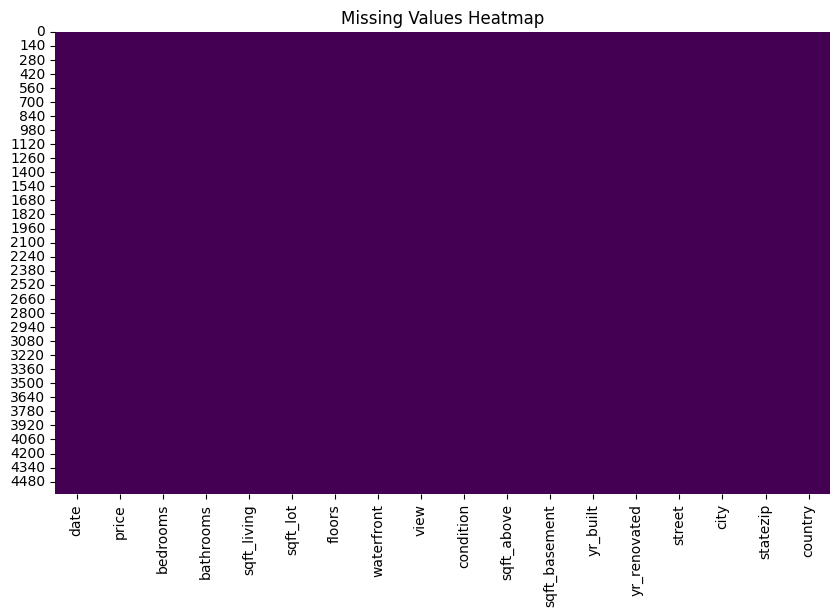

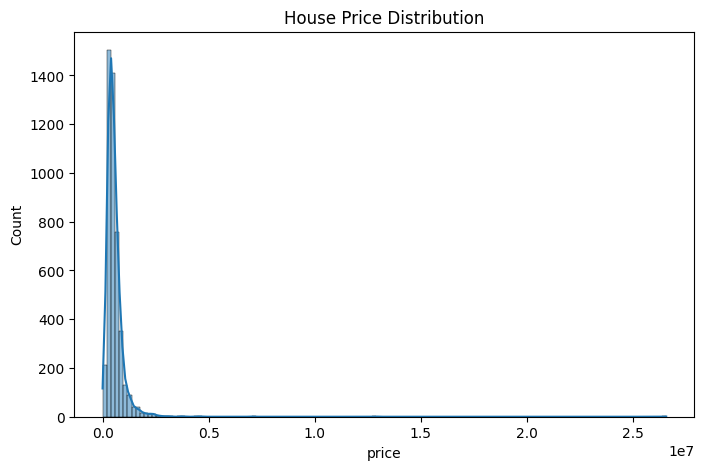

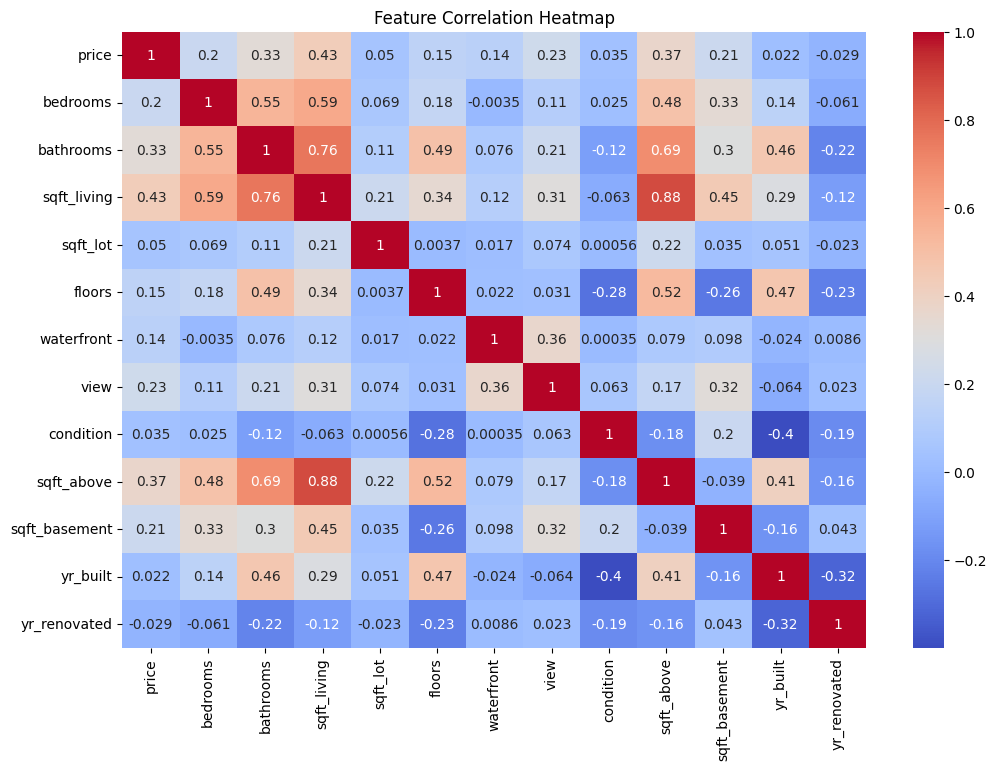

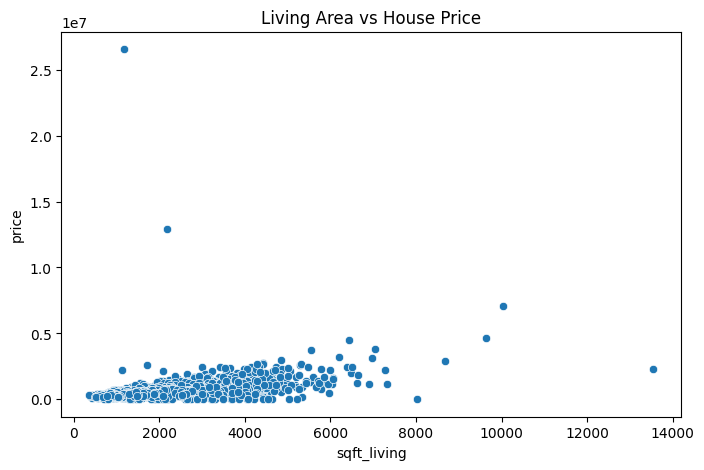

In [3]:
#EDA Visualization
#Missing Values HeatMap
plt.figure(figsize=(10,6))
sns.heatmap(
    data.isnull(),
    cbar=False,
    cmap='viridis'
)
plt.title("Missing Values Heatmap")
plt.show()

#House Value Distribution
plt.figure(figsize=(8,5))
sns.histplot(data['price'],kde=True)
plt.title("House Price Distribution")
plt.show()

#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation Heatmap")
plt.show()

#Scatter Plot (Feature vs Price)
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=data,
    x='sqft_living',
    y='price'
)
plt.title("Living Area vs House Price")
plt.show()


In [4]:
#Handling missing values
for col in data.columns:
    if not pd.api.types.is_string_dtype(
        data[col]
    ):
        data[col] = data[col].fillna(
            data[col].mean()
        )


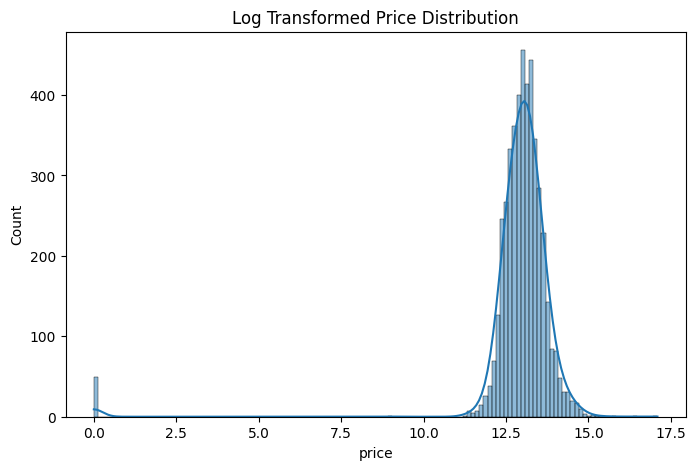

In [5]:
#Feature Transformation
#1. Log Transformation
data['price'] = np.log1p(data['price'])
plt.figure(figsize=(8,5))
sns.histplot(data['price'],kde=True)
plt.title("Log Transformed Price Distribution")
plt.show()

In [6]:
#Encoding
encoder = LabelEncoder()
categorical_cols = [
    'date',
    'street',
    'city',
    'statezip',
    'country'
]
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])
print(data[categorical_cols].head())    

   date  street  city  statezip  country
0     0    1522    36        62        0
1     0    3899    35        58        0
2     0    2291    18        26        0
3     0    4263     3         7        0
4     0    4352    31        31        0


In [7]:
#Scaling
x=data.drop('price',axis=1)
y=data['price']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

joblib.dump(scaler,'scaler.pkl')
print("Scaler saved successfully.")

Scaler saved successfully.


In [8]:
#Training Models
#1. Linear Regression
lr = LinearRegression()
lr.fit(x_train_scaled,y_train)
lr_pred = lr.predict(x_test_scaled)

#2. Random Forest
rf=RandomForestRegressor(random_state=42)
rf.fit(x_train_scaled,y_train)
rf_pred = rf.predict(x_test_scaled)

#3. Gradient Boosting
gb=GradientBoostingRegressor(random_state=42)
gb.fit(x_train_scaled,y_train)
gb_pred = gb.predict(x_test_scaled)

-----------------
Linear Regression
-----------------
RMSE: 1.385223567226349
MAE: 0.4682776998299161


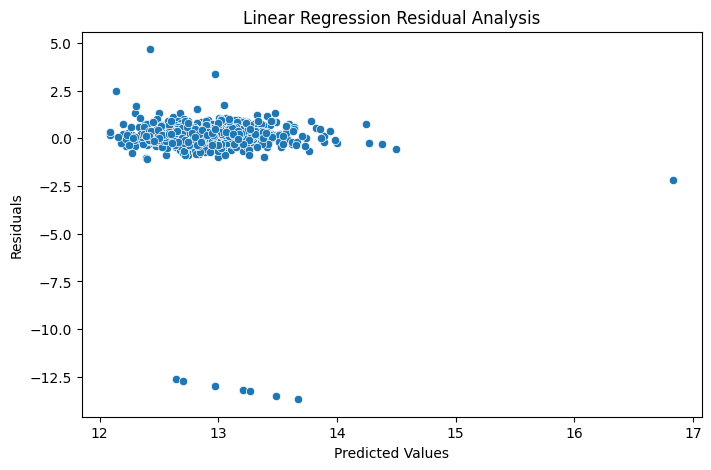

-------------
Random Forest
-------------
RMSE: 1.4656670089256494
MAE: 0.47871321955900453


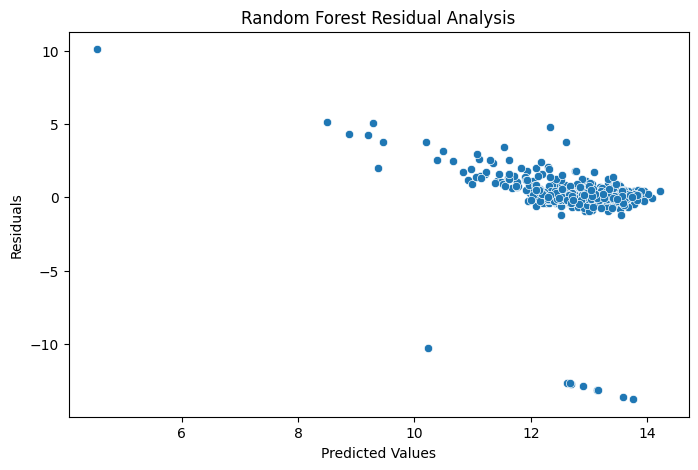

-----------------
Gradient Boosting
-----------------
RMSE: 1.474354593186124
MAE: 0.4760926156637219


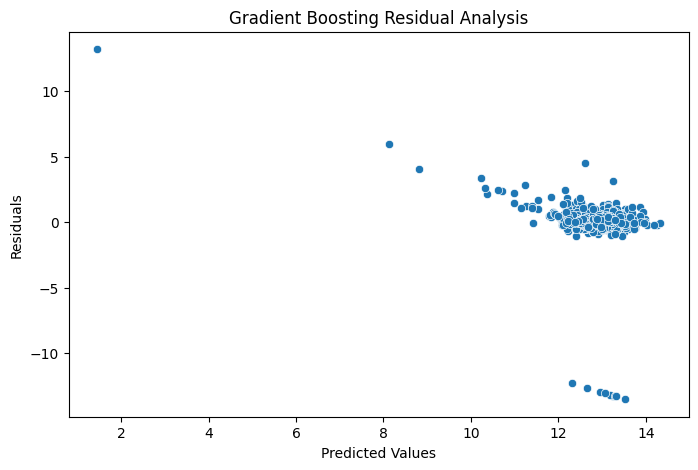

In [9]:
#Model Evaluation
def evaluate_model(name,y_actual,y_pred):
    rmse=root_mean_squared_error(y_actual,y_pred)
    mae=mean_absolute_error(y_actual,y_pred)
    print("-"*len(name)+f"\n{name}"+"\n"+"-"*len(name))
    print("RMSE:", rmse)
    print("MAE:", mae)

    residuals=y_actual - y_pred
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=y_pred,y=residuals)
    plt.title(f"{name} Residual Analysis")
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.show()
    return rmse

lr_rmse=evaluate_model("Linear Regression",y_test,lr_pred)
rf_rmse=evaluate_model("Random Forest",y_test,rf_pred)
gb_rmse=evaluate_model("Gradient Boosting",y_test,gb_pred)


In [10]:
#Selecting Best Model
models={
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}
model_rmse={
    "Linear Regression": lr_rmse,
    "Random Forest": rf_rmse,
    "Gradient Boosting": gb_rmse
}
best_model=min(model_rmse, key=model_rmse.get)
print(f"Best Model is {best_model} with RMSE {model_rmse[best_model]}")

joblib.dump(
    models[best_model],
    'best_price_model.pkl'
)
print("Best model saved successfully.")

Best Model is Linear Regression with RMSE 1.385223567226349
Best model saved successfully.


In [11]:
#How to use the saved model for prediction
import pandas as pd
import numpy as np
import joblib

# Load saved model
model_used = joblib.load(
    "best_price_model.pkl"
)

# Load scaler
scaler_used = joblib.load(
    "scaler.pkl"
)

# Example house input
sample = pd.DataFrame(
    [[
        2008,   # date
        3,      # bedrooms
        2,      # bathrooms
        1800,   # sqft_living
        5000,   # sqft_lot
        2,      # floors
        0,      # waterfront
        0,      # view
        3,      # condition
        1800,   # sqft_above
        0,      # sqft_basement
        1998,   # yr_built
        0,      # yr_renovated
        10,     # street (encoded)
        5,      # city (encoded)
        20,     # statezip (encoded)
        1       # country (encoded)
    ]],
    columns=x.columns
)

# Scale input
sample_scaled = scaler_used.transform(
    sample
)

# Predict
prediction = model_used.predict(
    sample_scaled
)

# Reverse log transformation
predicted_price = np.expm1(
    prediction
)

print("Predicted House Price:",f"{predicted_price[0]:.2f}")

Predicted House Price: 6551300.74
